## How are in-demand skills trending for Data Engineers?

#### Methology
1. Aggregate skill counts monthly
2. Re-analyze based on percentage of total jobs
3. Plot the monthly skill demand

In [1]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
from matplotlib import cm
import ast
import seaborn as sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\david\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_DE_Ger = df[(df['job_title_short'] == 'Data Engineer') & (df['job_country'] == 'Germany')].copy()

In [3]:
df_DE_Ger['job_posted_month_no'] = df_DE_Ger['job_posted_date'].dt.month

In [4]:
df_DE_Ger_explode = df_DE_Ger.explode('job_skills')

In [47]:
df_DE_Ger_pivot = df_DE_Ger_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)

df_DE_Ger_pivot.loc['Total'] = df_DE_Ger_pivot.sum()

df_DE_Ger_pivot = df_DE_Ger_pivot[df_DE_Ger_pivot.loc['Total'].sort_values(ascending=False).index]

df_DE_Ger_pivot = df_DE_Ger_pivot.drop('Total')

df_DE_Ger_pivot

job_skills,python,sql,azure,aws,spark,java,kafka,airflow,databricks,scala,...,nltk,airtable,erlang,f#,mlpack,flutter,symphony,sqlite,jquery,zoom
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,329,316,214,181,152,120,98,110,73,68,...,0,0,0,0,0,0,0,0,0,1
2,312,252,177,144,146,121,90,76,78,75,...,0,0,0,0,0,0,0,0,0,0
3,287,256,144,135,99,79,79,85,66,56,...,0,0,0,0,0,0,0,0,1,0
4,267,225,125,134,114,71,73,99,55,55,...,0,0,0,1,1,0,0,0,0,0
5,212,167,121,106,69,60,57,70,33,44,...,1,0,0,0,0,0,1,0,0,0
6,246,219,134,119,96,80,70,53,57,55,...,0,0,0,0,0,0,0,0,0,0
7,269,213,150,141,92,81,62,55,45,58,...,0,0,0,0,0,0,0,0,0,0
8,187,177,118,80,83,69,57,56,39,35,...,0,0,0,0,0,0,0,0,0,0
9,337,315,197,145,131,114,84,52,80,72,...,0,1,1,0,0,0,0,0,0,0


In [30]:
df_DE_Ger_totals = df_DE_Ger.groupby('job_posted_month_no').size()

df_DE_Ger_percentage = df_DE_Ger_pivot.div(df_DE_Ger_totals/100, axis=0)

df_DE_Ger_percentage = df_DE_Ger_percentage.reset_index()
df_DE_Ger_percentage['job_posted_month'] = df_DE_Ger_percentage['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DE_Ger_percentage = df_DE_Ger_percentage.drop('job_posted_month_no', axis=1)
df_DE_Ger_percentage = df_DE_Ger_percentage.set_index('job_posted_month')

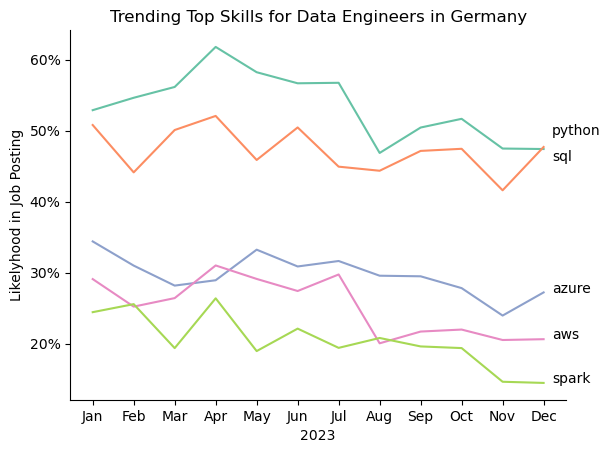

In [ ]:
from matplotlib.ticker import PercentFormatter

df_plot = df_DE_Ger_percentage.iloc[:,:5]
sns.lineplot(df_plot, dashes=False, palette='Set2')
plt.title('Trending Top Skills for Data Engineers in Germany')
plt.ylabel('Likelyhood in Job Posting')
plt.xlabel('2023')
plt.legend().remove()
sns.despine()

ax=plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

for i in range(5):
    col = df_plot.columns[i]
    y = df_plot.iloc[-1, i]

    if col.lower() == "python":
        y = y + 2
    elif col.lower() == "sql":
        y = y - 2

    plt.text(11.2, y, col)

